In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

from matplotlib.colors import LogNorm, Normalize, CenteredNorm

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics




/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-03-17 16:50:48,542	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
amp_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/6nm_surfPSD/'

wfe_optic = 12

# Ignore OAP7 So that doesn't add any WFE when we compute the flat
opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    # 'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

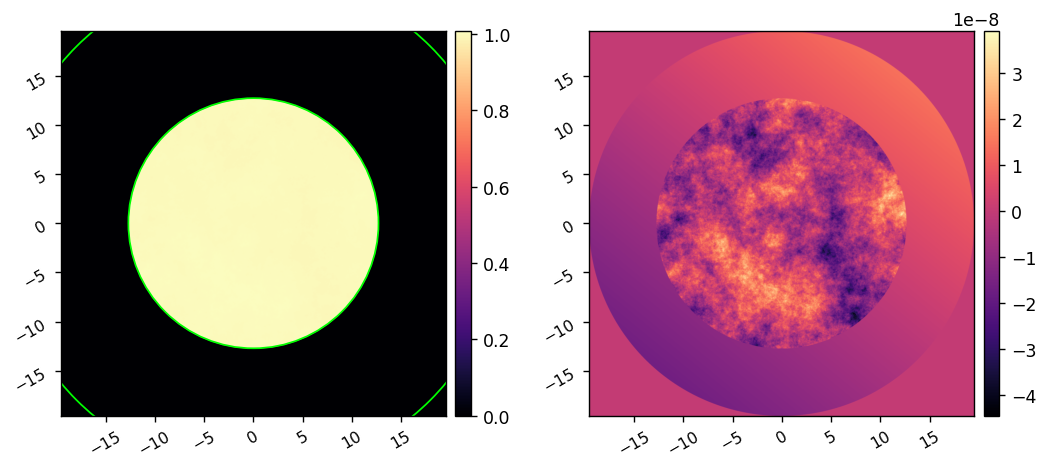

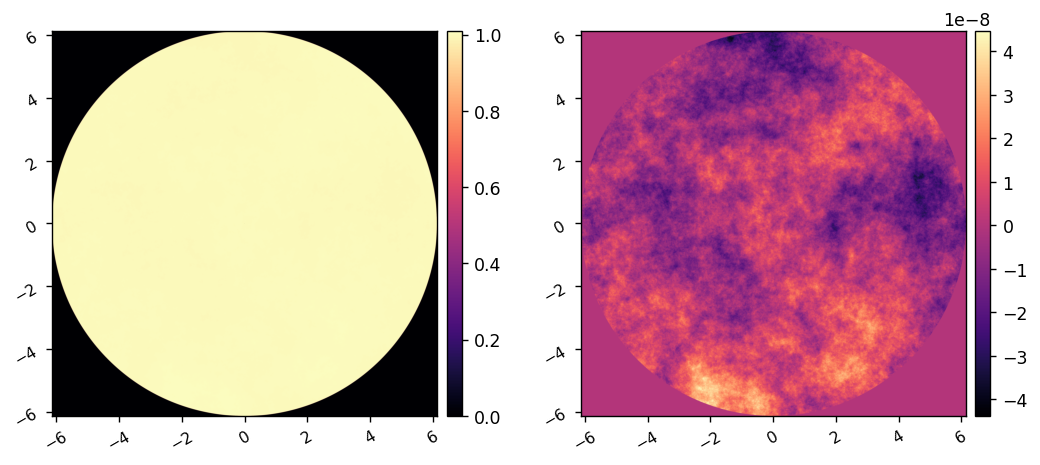

In [5]:
optic = 'oap2'
# optic = 'input_lp'
imshow2(
    M.wfes[optic].amplitude, M.wfes[optic].opd, pxscl=M.wfes[optic].pixelscale.to(u.mm/u.pix), 
    patches1=[Circle((0,0), 25.4/2, fill=False, color='lime'), Circle((0,0), 25.4, fill=False, color='lime')],
)

optic = 'oap10'
imshow2(
    M.wfes[optic].amplitude, M.wfes[optic].opd, pxscl=M.wfes[optic].pixelscale.to(u.mm/u.pix), 
    patches1=[Circle((0,0), 25.4/2, fill=False, color='lime'), Circle((0,0), 25.4, fill=False, color='lime')],
)

In [3]:
reload(esc)
M = esc.single()
M.wfes = wfes

1


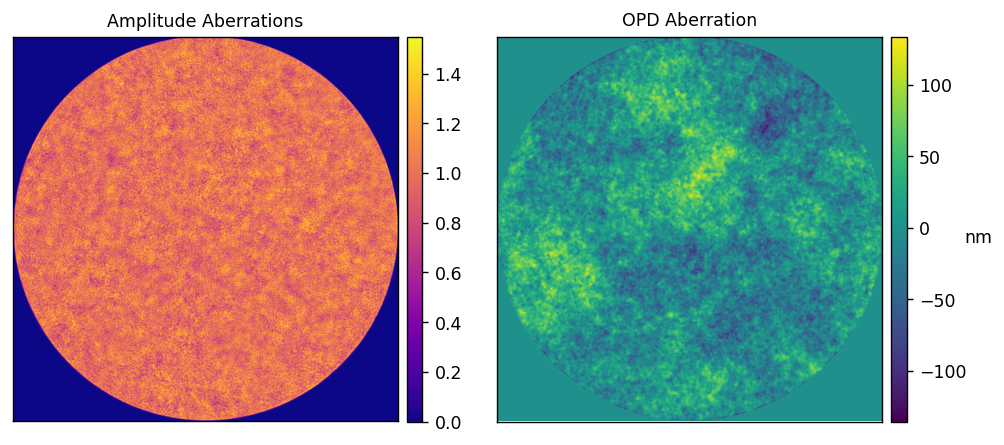

In [4]:
M.return_lyot = True
M.npix = 1000
M.oversample = 2.048
M.use_vortex = False
lyot_wfe = utils.pad_or_crop(M.calc_pupil(), M.npix)
lyot_amp = xp.abs(lyot_wfe) * M.GAP_MASK
lyot_phs = xp.angle(lyot_wfe) * M.GAP_MASK
lyot_opd = lyot_phs * M.wavelength_c.to_value(u.m) / (2*xp.pi)
lyot_wfe = lyot_amp * xp.exp(1j*lyot_phs)
imshow(
    [xp.abs(lyot_amp), lyot_opd*1e9],
    titles=['Amplitude Aberrations', 'OPD Aberration'],
    xticks=[[], []],
    yticks=[[], []],
    cbar_labels=[None, 'nm'],
    cmaps=['plasma', 'viridis'],
    wspace=0
)
# imshow3(xp.abs(lyot_wfe), xp.angle(lyot_wfe), lyot_opd)

1.0
(952,) <class 'numpy.ndarray'>


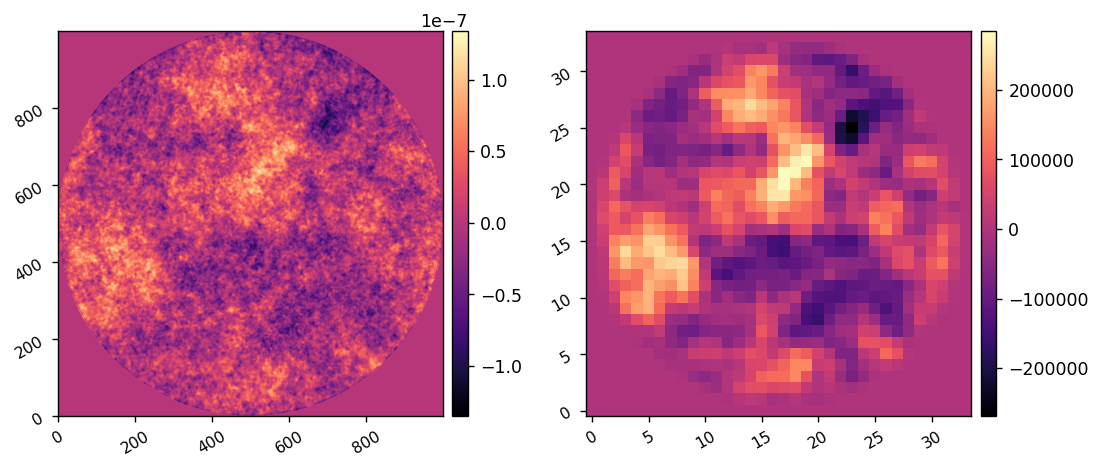

In [5]:
def val_and_grad(
        del_acts, 
        OPD, 
        M, 
        current_acts=np.zeros((M.Nact,M.Nact)) 
    ):

    del_acts = xp.array(del_acts)
    OPD = xp.array(OPD)

    del_command = xp.zeros((M.Nact, M.Nact))
    del_command[M.dm_mask] = xp.array(del_acts)

    current_acts = xp.array(current_acts)

    dm_command = current_acts + del_command
    dm_mft = M.DM.Mx@dm_command@M.DM.My
    dm_surf_fft = M.DM.inf_fun_fft * dm_mft
    dm_surf = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(dm_surf_fft,))).real
    dm_surf = utils.pad_or_crop(dm_surf, M.npix)

    opd_l2norm = OPD[M.BAP_MASK].dot(OPD[M.BAP_MASK])
    total_opd =  OPD + 2*dm_surf
    J = total_opd[M.BAP_MASK].dot(total_opd[M.BAP_MASK]) / opd_l2norm
    print(J)

    masked_total = M.GAP_MASK * total_opd
    dJ_dOPD = 2 * (masked_total) / opd_l2norm

    dJ_dS_DM = utils.pad_or_crop(dJ_dOPD, M.DM.Nsurf)
    x2_bar = xp.fft.fftshift(xp.fft.fft2(xp.fft.ifftshift(dJ_dS_DM)))
    x1_bar = x2_bar * M.DM.inf_fun_fft.conj()
    dJ_dA1 = M.DM.Mx.T.conj()@x1_bar@M.DM.My.T.conj() / ( M.DM.Nsurf * M.Nact * M.Nact )

    dJ_dA = dJ_dA1[M.dm_mask].real

    return ensure_np_array(J), ensure_np_array(dJ_dA)

del_acts = xp.zeros(M.Nacts)
J0, dJ_dA = val_and_grad(del_acts, lyot_opd, M)
print(dJ_dA.shape, type(dJ_dA))

dm_grad = xp.zeros((M.Nact, M.Nact))
dm_grad[M.dm_mask] = xp.array(dJ_dA)
imshow2(lyot_opd, dm_grad)

1.0
12170043447315.123
0.7520999513446107
0.3986856252081626
0.3854251731932711
0.36783882810827134
0.36586163409092953
0.36347099872716426
0.3623450585729927
0.3615961831440893
0.361206975868167
0.3606379421955723
0.36049971407986187
0.3602901335171885
0.3602396106667745


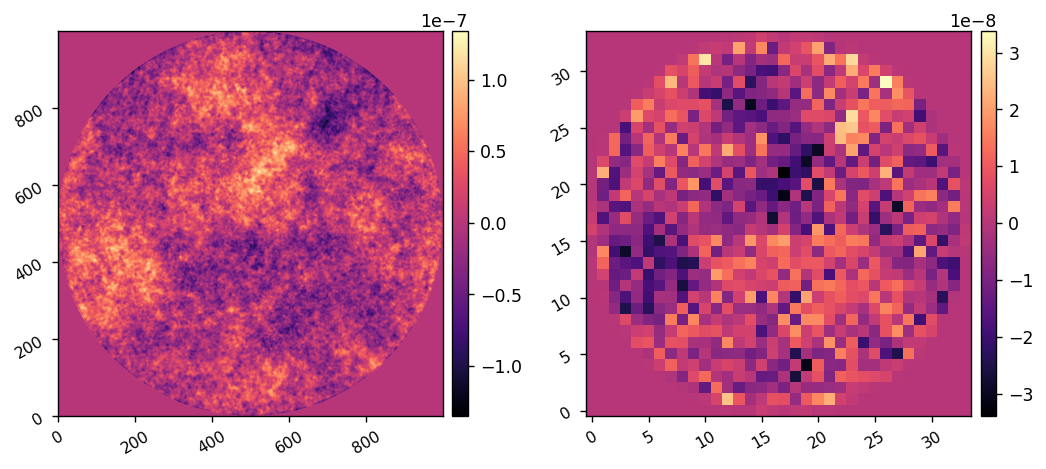

In [6]:
from scipy.optimize import minimize

bfgs_tol = 1e-4
options = {
    'disp':1, 
    # 'maxiter':30,
    # 'maxls':100, # default is 20
    # 'ftol':1e-6, 
    # 'gtol':1e-6,
}
del_acts0 = np.zeros(M.Nacts)
res = minimize(
    val_and_grad, 
    jac=True, 
    x0=del_acts0, 
    args=(lyot_opd, M),
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=options,
)

flat_command = xp.zeros((M.Nact, M.Nact))
flat_command[M.dm_mask] = xp.array(res.x)
imshow2(lyot_opd, flat_command,)

flat_command = xp.rot90(xp.rot90(flat_command))

In [7]:
amp_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/reflectivity_maps_2024_09_15/'
opd_dir = '/home/kianmilani/Projects/esc-fresnel/esc_fresnel/wfe-maps/6nm_surfPSD/'

wfe_optic = 12

opd_rms_vals = {
    'm1': 2*21*u.nm, 
    'm2': 2*8*u.nm, 
    'm3': 2*6*u.nm, 
    'm4': 2*12*u.nm, 
    'oap1': wfe_optic*u.nm,
    'fm1': wfe_optic*u.nm, 
    'oap2': wfe_optic*u.nm, 
    'oap3': wfe_optic*u.nm, 
    'fsm': wfe_optic*u.nm, 
    'fm2': wfe_optic*u.nm, 
    'oap4': wfe_optic*u.nm, 
    'oap5': wfe_optic*u.nm, 
    'input_lp': wfe_optic*u.nm, 
    'input_qwp': wfe_optic*u.nm, 
    'oap6': wfe_optic*u.nm, 
    'oap7': wfe_optic*u.nm, 
    'oap9': wfe_optic*u.nm, 
    'collimator': wfe_optic*u.nm, 
    'filter': wfe_optic*u.nm, 
    'output_qwp': wfe_optic*u.nm,
    'output_lp': wfe_optic*u.nm, 
    'oap10': wfe_optic*u.nm, 
}

wfes = {}
for optic in opd_rms_vals.keys():
    wfe = poppy.FITSOpticalElement(
        opd=opd_dir + f'{optic}_subap.fits', 
        opdunits='nanometers',
        transmission=amp_dir + f'{optic}_amp_subap_1000px.fits',
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

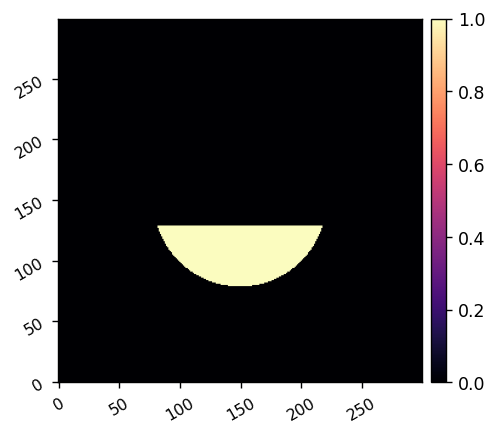

1


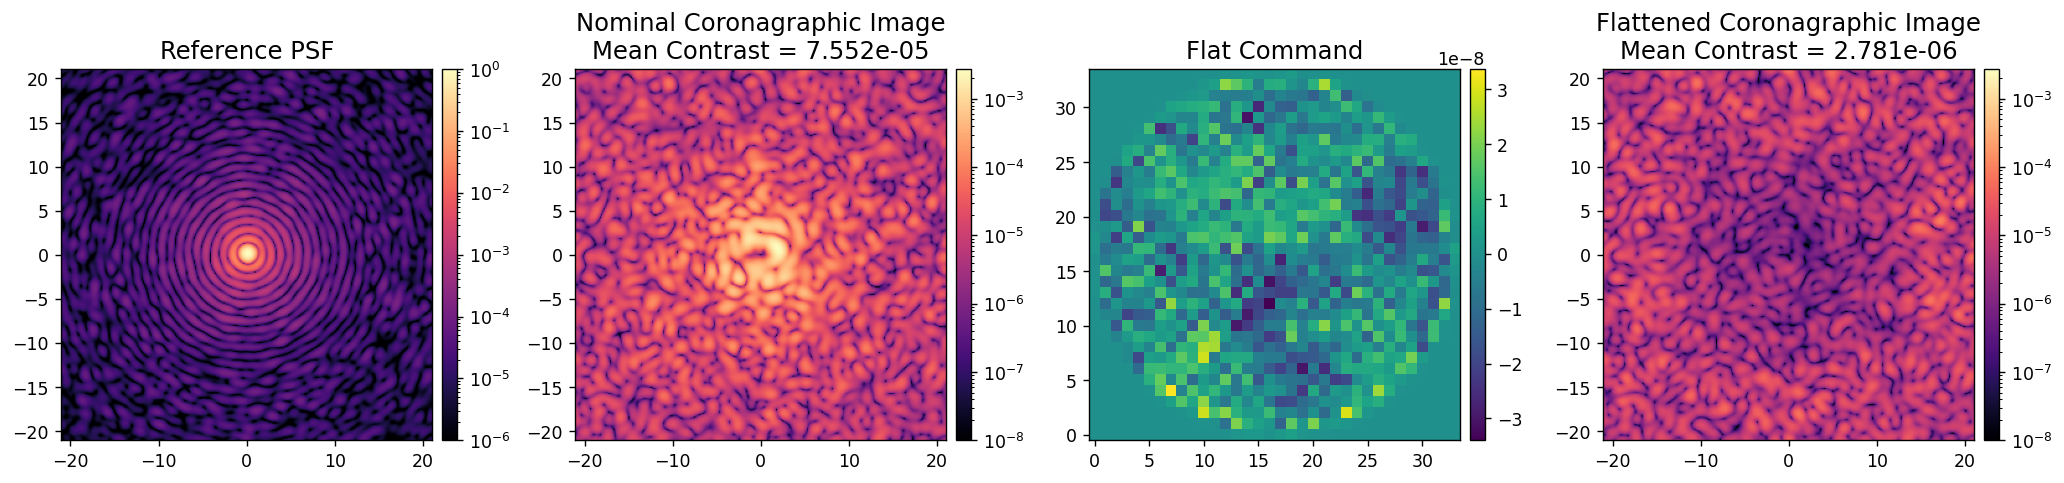

In [12]:
reload(esc)
M = esc.single(
    npix=1000,
    oversample=4.096,
)
M.wfes = wfes

M.npsf = 300

M.set_dm(flat_command)
M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.zero_dm()
M.use_vortex = True
coro_im_0 = M.snap()

M.set_dm(flat_command)
coro_im_flat = M.snap()

coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=3, 
    orad=10,
    edge=3,
    rotation=90,
)
imshow1(coro_mask)

contrast_0 = utils.mean(coro_im_0, coro_mask)
contrast_flat = utils.mean(coro_im_flat, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_0, flat_command, coro_im_flat,],
    titles=[f'Reference PSF',
            f'Nominal Coronagraphic Image\nMean Contrast = {contrast_0:.3e}',
            'Flat Command', 
            f'Flattened Coronagraphic Image\nMean Contrast = {contrast_flat:.3e}',],
    title_fzs=[14]*4,
    norms=[LogNorm(1e-6), LogNorm(1e-8, np.max(coro_im_0)), None, LogNorm(1e-8, np.max(coro_im_0))],
    cmaps=['magma', 'magma', None, 'magma'],
    pxscls=[M.camsci_pxscl_lamDc, M.camsci_pxscl_lamDc, None, M.camsci_pxscl_lamDc],
    wspace=0.3,
    figsize=(20,8),
)

In [9]:
utils.save_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_flat.fits', flat_command)

Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/dm-commands/esc_fresnel_dm_flat.fits
